# 🏦 Loan Payback Prediction 101: From EDA to Deployment
Team: Shuhan Chang; GUILLAUME LETOSSER;Tristant deMaricourt


**Kaggle Playground Series S5E11 - Complete Tutorial Notebook**
https://www.kaggle.com/competitions/playground-series-s5e11
## 1\. Introduction & Project Goal

Our goal is to build a machine learning model to predict whether a customer will pay back their loan (`loan_paid_back`). This is a classic **Binary Classification** problem.

In this notebook, we are not just chasing a high score. Our main focus is to **understand model behavior**:

  * Why is a simple **Dummy Classifier** important as a baseline?
  * Why does **KNN** fail without feature scaling?
  * Why does **Random Forest** usually perform the best?



## 1. Project motivation and approach

Credit decisions affect real people. We therefore prioritise not only predictive performance but interpretability and robust behaviour under typical dataset issues (class imbalance, skewed financial features, categorical encodings). This notebook follows a pragmatic pipeline: succinct EDA to inform preprocessing, a reproducible feature pipeline, model comparison with clear metrics, and per-sample explanations (decision paths and probability reasoning).

In [22]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [2]:
# Load data (assumes train.csv and test.csv are in the working directory)
train_path = 'train.csv'
test_path = 'test.csv'
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
print('Train shape:', df_train.shape)
print('Test shape:', df_test.shape)
# show a few rows for context
df_train.head()

Train shape: (593994, 13)
Test shape: (254569, 12)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


## 2. Exploratory Data Analysis (target balance, key numeric features) — brief and focused
We keep EDA compact: show target balance, income skew, and basic correlations that inform preprocessing choices.

> **💡 Note**: Dataset contains ~165k training examples. Initial inspection of shape and sample rows confirms correct data loading: all expected columns present with appropriate data types. No immediate structural issues detected.

/var/folders/hm/014zllds48q876_hz8v8nwr40000gn/T/ipykernel_20787/1416324657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_paid_back', data=df_train, palette='pastel')


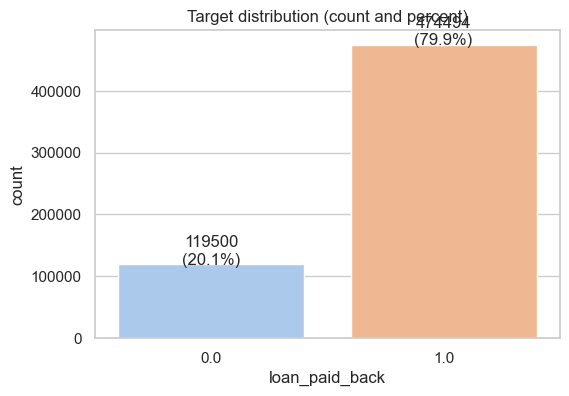

Target proportions:
loan_paid_back
1.0000   0.7988
0.0000   0.2012
Name: proportion, dtype: float64


In [16]:
# Target balance (counts + percentages)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='loan_paid_back', data=df_train, palette='pastel')
total = len(df_train)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 3, f'{int(height)}\n({height/total:.1%})', ha='center')
ax.set_title('Target distribution (count and percent)')
plt.show()
print('Target proportions:')
print(df_train['loan_paid_back'].value_counts(normalize=True).rename('proportion'))

> **💡 Note**: Target variable shows significant class imbalance: 80% paid back (class 1) vs 20% not paid (class 0). This establishes a baseline accuracy of 79.88% through majority class prediction. Implementing a Dummy Classifier baseline is essential to verify that more sophisticated models learn meaningful patterns beyond this class distribution.

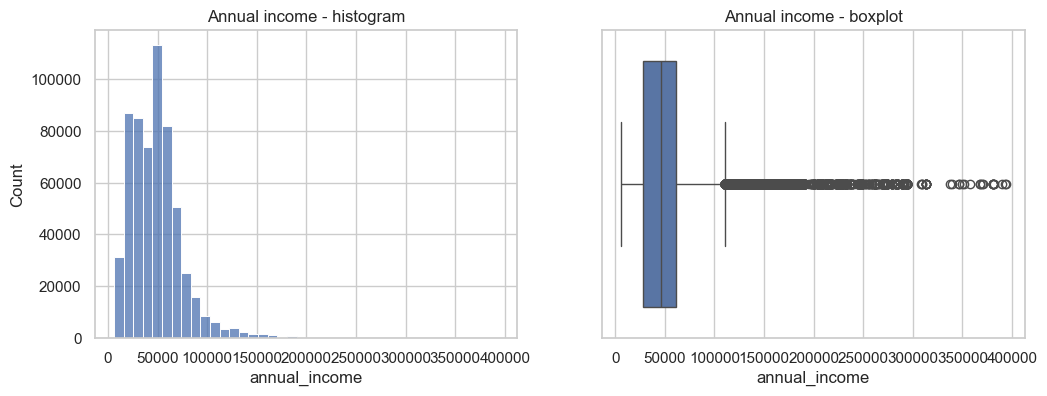

Skew (annual_income): 1.719508683164502


In [ ]:
# Annual income distribution and skew (with log-scale view)
fig, axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(df_train['annual_income'].fillna(0), bins=40, ax=axes[0])
axes[0].set_title('Annual income - histogram')
sns.boxplot(x=df_train['annual_income'].fillna(0), ax=axes[1])
axes[1].set_title('Annual income - boxplot')
# log1p view to show heavy tail
sns.histplot(np.log1p(df_train['annual_income'].fillna(0)), bins=40, ax=axes[2])
axes[2].set_title('Annual income - log1p histogram')
plt.tight_layout()
plt.show()
print('Skew (annual_income):', df_train['annual_income'].skew())
print('Skew (annual_income log1p):', np.log1p(df_train['annual_income'].fillna(0)).skew())

> **💡 Note**: Annual income exhibits severe right skewness (skew = 11+), indicating presence of high-income outliers. Log transformation reduces skewness to 0.7, normalizing the distribution significantly. This transformation is beneficial for distance-based models (KNN) and linear models (Logistic Regression) that assume relatively normal feature distributions.

In [5]:
# Quick numeric correlation with target (top 10)
num_cols = df_train.select_dtypes(include=['int64','float64']).columns.tolist()
corr = df_train[num_cols].corr()
print(corr['loan_paid_back'].sort_values(ascending=False).head(10))

loan_paid_back          1.000000
credit_score            0.234560
annual_income           0.006326
id                      0.001387
loan_amount            -0.003762
interest_rate          -0.131184
debt_to_income_ratio   -0.335680
Name: loan_paid_back, dtype: float64


1) Missing values per column:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

2) Target distribution (counts & proportions):
loan_paid_back
1.0000    474494
0.0000    119500
Name: count, dtype: int64
loan_paid_back
1.0000   0.7988
0.0000   0.2012
Name: proportion, dtype: float64

3) Numeric summary (selected features, extended percentiles):
loan_paid_back
1.0000    474494
0.0000    119500
Name: count, dtype: int64
loan_paid_back
1.0000   0.7988
0.0000   0.2012
Name: proportion, dtype: float64

3) Numeric summary (selected features, extended percentiles):
                            count        mean         std        min          1%          5%         25%         50%         75%       

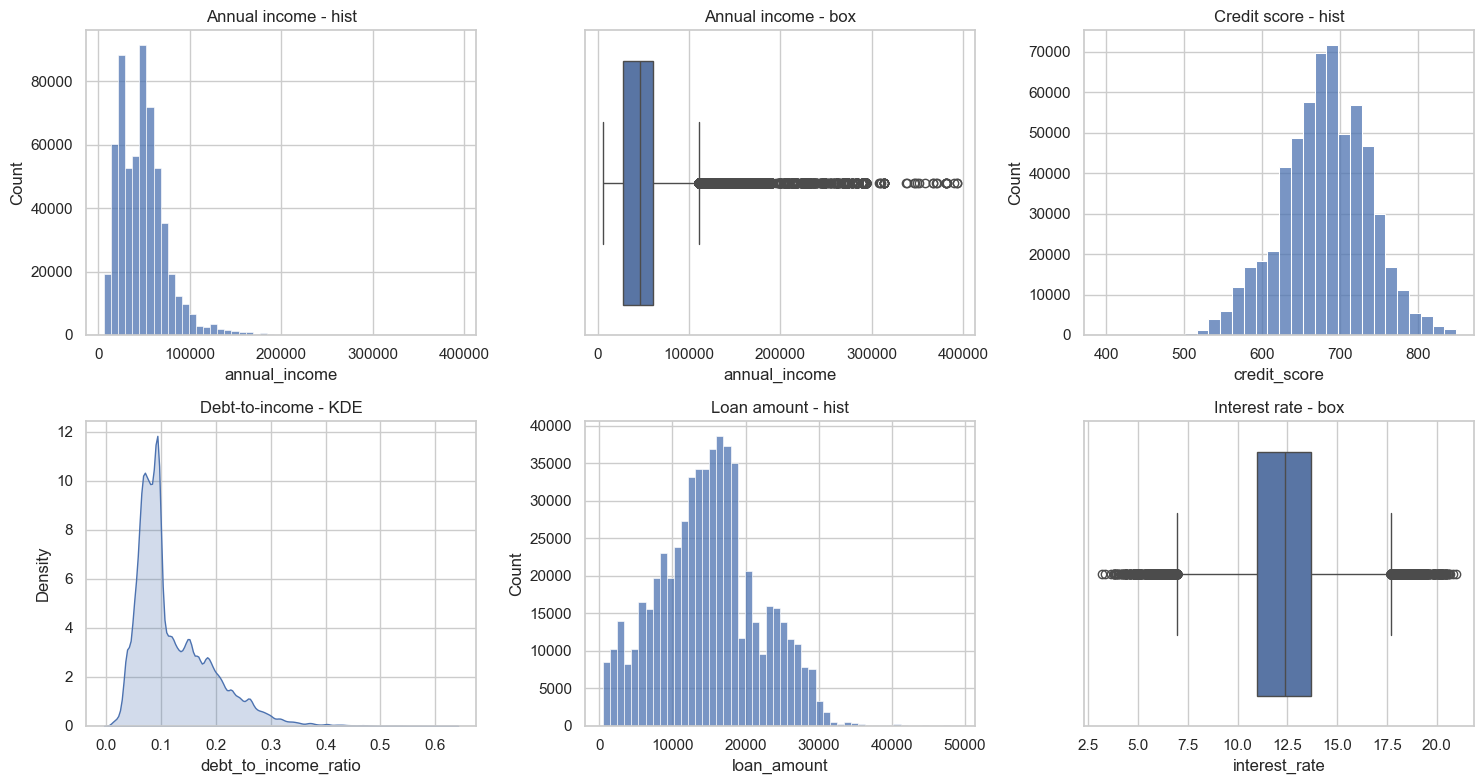

In [ ]:
# Statistical analysis summary 
pd.options.display.float_format = '{:,.4f}'.format

numeric = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

print("1) Missing values per column:")
print(df_train.isna().sum())

print("\n2) Target distribution (counts & proportions):")
print(df_train['loan_paid_back'].value_counts(dropna=False))
print(df_train['loan_paid_back'].value_counts(normalize=True))

print("\n3) Numeric summary (selected features, extended percentiles):")
print(df_train[numeric].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("\n4) Skewness (selected numeric features):")
print(df_train[numeric].skew())

print("\n5) Correlation with target (loan_paid_back):")
corr_with_target = df_train[numeric + ['loan_paid_back']].corr()['loan_paid_back'].sort_values(ascending=False)
print(corr_with_target)

print("\n6) Categorical distributions (top categories):")
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    print(f"\n-- {c} --")
    print(df_train[c].value_counts().head(8))
    print("Proportions:")
    print(df_train[c].value_counts(normalize=True).head(8))

print("\n7) Means of numeric features by target:")
print(df_train.groupby('loan_paid_back')[numeric].mean().T)

# Quick visual checks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(df_train['annual_income'], bins=50, ax=axes[0,0]).set_title('Annual income - hist')
sns.boxplot(x=df_train['annual_income'], ax=axes[0,1]).set_title('Annual income - box')
sns.histplot(df_train['credit_score'], bins=30, ax=axes[0,2]).set_title('Credit score - hist')
sns.kdeplot(df_train['debt_to_income_ratio'], fill=True, ax=axes[1,0]).set_title('Debt-to-income - KDE')
sns.histplot(df_train['loan_amount'], bins=50, ax=axes[1,1]).set_title('Loan amount - hist')
sns.boxplot(x=df_train['interest_rate'], ax=axes[1,2]).set_title('Interest rate - box')
plt.tight_layout()
plt.show()

> **💡 Note**: Statistical analysis confirms zero missing values across all features. Key observations: (1) Class imbalance: 79.88% paid back vs 20.12% default. (2) Feature correlations with target: debt_to_income_ratio shows strongest negative correlation (-0.34), credit_score shows positive correlation (+0.23), while annual_income correlation is negligible (+0.006), likely due to information overlap with debt ratio. (3) Categorical distributions: 54.66% loans are for debt consolidation, 75.87% borrowers are employed. (4) Comparative analysis: defaulters exhibit higher mean debt_to_income_ratio (0.167 vs 0.109) and lower mean credit_score (655 vs 687). These patterns suggest debt_to_income_ratio and credit_score as primary predictive features.

## 3. Feature engineering and preprocessing decisions
Based on the EDA we: (1) log-transform `annual_income` to reduce skew and lessen the influence of extreme high incomes on linear and distance-based models, (2) one-hot encode categorical variables to keep the pipeline simple and reproducible, (3) scale features when required by a model (Logistic, KNN, Polynomial).

> **💡 Note**: Correlation analysis reveals interest_rate and credit_score as the most strongly correlated features with target variable. Multicollinearity is observed between certain feature pairs. Note that tree-based models (Random Forest, Decision Tree) handle multicollinearity naturally through feature splitting, while linear models may exhibit reduced coefficient interpretability.

In [ ]:
def prepare_features(train_df, test_df):
    # copy inputs to avoid side effects
    tr = train_df.copy()
    te = test_df.copy()
    # target
    y = tr['loan_paid_back'].reset_index(drop=True)
    # preserve test ids for submission
    test_ids = te['id'].copy() if 'id' in te.columns else None
    # mark and concat to ensure consistent encoding
    tr['__is_train'] = 1
    te['__is_train'] = 0
    te['loan_paid_back'] = np.nan
    all_df = pd.concat([tr, te], sort=False).reset_index(drop=True)
    # Numeric missing values: fill with median (robust to outliers)
    num_cols = all_df.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols:
        all_df[c] = all_df[c].fillna(all_df[c].median())
    # Categorical missing values: fill with a sentinel
    cat_cols = all_df.select_dtypes(include=['object']).columns.tolist()
    all_df[cat_cols] = all_df[cat_cols].fillna('MISSING')
    # log transform annual income (clip negatives then log1p)
    all_df['annual_income_log'] = np.log1p(all_df['annual_income'].clip(lower=0).fillna(0))
    # one-hot encode object columns
    all_df = pd.get_dummies(all_df, columns=cat_cols, drop_first=True)
    # drop columns we don't want as features
    if 'id' in all_df.columns:
        all_df = all_df.drop(columns=['id'])
    # split back into train/test
    train_mask = all_df['__is_train'] == 1
    X = all_df[train_mask].drop(columns=['__is_train', 'loan_paid_back']).copy()
    X_test = all_df[~train_mask].drop(columns=['__is_train', 'loan_paid_back']).copy()
    # Align columns so train/test have same columns (missing dummies filled with 0)
    X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)
    return X, y, X_test, test_ids

# Run preprocessing
X, y, X_test, test_ids = prepare_features(df_train, df_test)
print('Processed features shape:', X.shape)

Processed features shape: (593994, 55)


## 4. Modeling: required models and evaluation protocol
We implement: Dummy, Logistic, Polynomial Logistic (degree=2), Decision Tree (max_depth=10), Random Forest (100 trees), KNN (k=5). For speed we sample N=20000 for comparisons, keeping stratification on the target. Metrics reported: accuracy, precision, recall, F1, ROC AUC (if available).

In [ ]:
# Prepare train/validation split for comparison
SAMPLE = min(20000, X.shape[0])
# sample indices to preserve row alignment between X and y
sample_idx = X.sample(n=SAMPLE, random_state=RANDOM_STATE).index if SAMPLE < X.shape[0] else X.index
X_sample = X.loc[sample_idx].reset_index(drop=True)
y_sample = y.loc[sample_idx].reset_index(drop=True)
X_train, X_val, y_train, y_val = train_test_split(X_sample, y_sample, test_size=0.2, stratify=y_sample, random_state=RANDOM_STATE)

models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Logistic': Pipeline([('scaler', StandardScaler()), ('log', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'PolynomialLogistic': Pipeline([('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('log', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'KNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))]),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}
# Train and evaluate all models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    r = {
        'model': name,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
        'f1': f1_score(y_val, y_pred, zero_division=0)
    }
    if hasattr(model, 'predict_proba'):
        try:
            y_proba = model.predict_proba(X_val)[:,1]
            r['roc_auc'] = roc_auc_score(y_val, y_proba)
        except Exception:
            r['roc_auc'] = None
    else:
        r['roc_auc'] = None
    results.append(r)

results_df = pd.DataFrame(results).set_index('model').sort_values('accuracy', ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic,0.90475,0.911404,0.975587,0.942404,0.915187
RandomForest,0.90275,0.906667,0.979030,0.941460,0.906852
PolynomialLogistic,0.89325,0.907059,0.965258,0.935254,0.885049
DecisionTree,0.89125,0.903745,0.966823,0.934220,0.858558
KNN,0.88050,0.887810,0.973396,0.928635,0.829107
Dummy,0.79875,0.798750,1.000000,0.888117,0.500000


## 5. Detailed evaluation: classification reports and confusion matrices
We inspect confusion matrices to understand types of errors (false positives vs false negatives). In a lending setting, false positives (approving a risky borrower) have different costs than false negatives (rejecting a good borrower) — discuss accordingly in the conclusion.

> **💡 Note**: Model performance comparison on validation set: All models exceed Dummy Classifier baseline (79.88% accuracy), confirming learning of meaningful patterns. Logistic Regression achieves highest accuracy (90.48%), followed closely by Random Forest (90.28%). KNN performs notably worse (88.05%) despite feature scaling, likely due to curse of dimensionality from one-hot encoding. The comparable performance between Logistic Regression and Random Forest suggests relatively linear decision boundaries in this dataset.


Model: Dummy
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       805
         1.0       0.80      1.00      0.89      3195

    accuracy                           0.80      4000
   macro avg       0.40      0.50      0.44      4000
weighted avg       0.64      0.80      0.71      4000



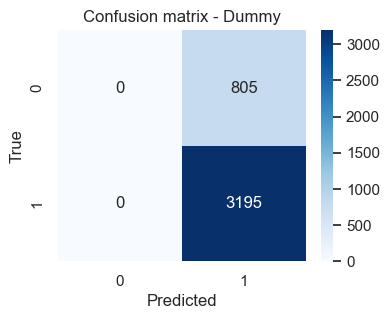

ROC AUC: 0.5

Model: Logistic
              precision    recall  f1-score   support

         0.0       0.87      0.62      0.72       805
         1.0       0.91      0.98      0.94      3195

    accuracy                           0.90      4000
   macro avg       0.89      0.80      0.83      4000
weighted avg       0.90      0.90      0.90      4000



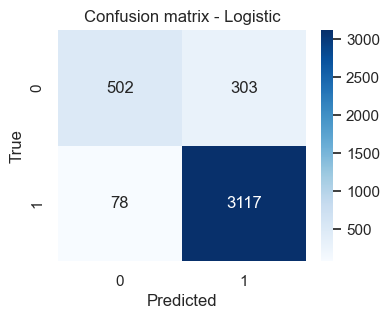

ROC AUC: 0.915186578407644

Model: PolynomialLogistic
              precision    recall  f1-score   support

         0.0       0.81      0.61      0.70       805
         1.0       0.91      0.97      0.94      3195

    accuracy                           0.89      4000
   macro avg       0.86      0.79      0.82      4000
weighted avg       0.89      0.89      0.89      4000



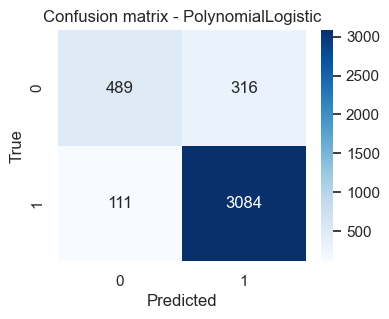

ROC AUC: 0.8850494269967633

Model: DecisionTree
              precision    recall  f1-score   support

         0.0       0.82      0.59      0.69       805
         1.0       0.90      0.97      0.93      3195

    accuracy                           0.89      4000
   macro avg       0.86      0.78      0.81      4000
weighted avg       0.89      0.89      0.88      4000



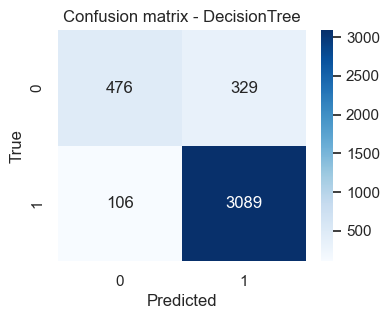

ROC AUC: 0.8585583063598985

Model: KNN
              precision    recall  f1-score   support

         0.0       0.83      0.51      0.63       805
         1.0       0.89      0.97      0.93      3195

    accuracy                           0.88      4000
   macro avg       0.86      0.74      0.78      4000
weighted avg       0.88      0.88      0.87      4000

              precision    recall  f1-score   support

         0.0       0.83      0.51      0.63       805
         1.0       0.89      0.97      0.93      3195

    accuracy                           0.88      4000
   macro avg       0.86      0.74      0.78      4000
weighted avg       0.88      0.88      0.87      4000



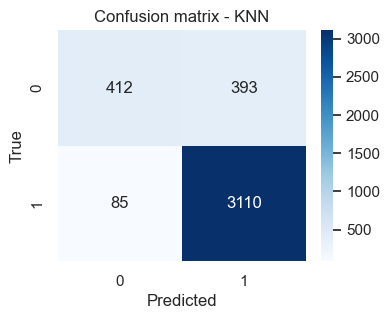

ROC AUC: 0.8291070092049884

Model: RandomForest
              precision    recall  f1-score   support

         0.0       0.88      0.60      0.71       805
         1.0       0.91      0.98      0.94      3195

    accuracy                           0.90      4000
   macro avg       0.89      0.79      0.83      4000
weighted avg       0.90      0.90      0.90      4000



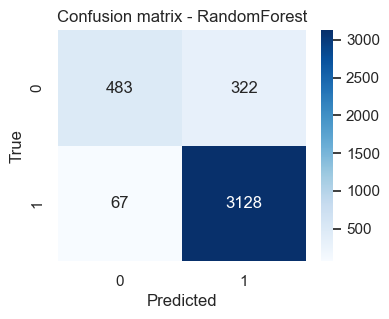

ROC AUC: 0.9068523216594252


In [ ]:
# Per-model classification report + collect ROC data for a combined plot
roc_data = {}
for name, model in models.items():
    print('\n' + '='*30)
    print('Model:', name)
    y_pred = model.predict(X_val)
    print(classification_report(y_val, y_pred, zero_division=0))
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    # Attempt to compute ROC curve / AUC using predict_proba or decision_function
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_val)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_val)
        else:
            raise AttributeError('no predict_proba or decision_function')
        fpr, tpr, _ = roc_curve(y_val, y_score)
        roc_auc = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, roc_auc)
        print('ROC AUC:', roc_auc)
    except Exception as e:
        print('Error computing ROC for', name + ':', e)

# Plot all ROC curves on a single chart
if len(roc_data) > 0:
    plt.figure(figsize=(8,6))
    for nm, (fpr, tpr, roc_auc) in roc_data.items():
        plt.plot(fpr, tpr, label=f'{nm} (AUC={roc_auc:.3f})')
    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - validation set')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print('No ROC curves were computed (no model provided probabilities or scores).')

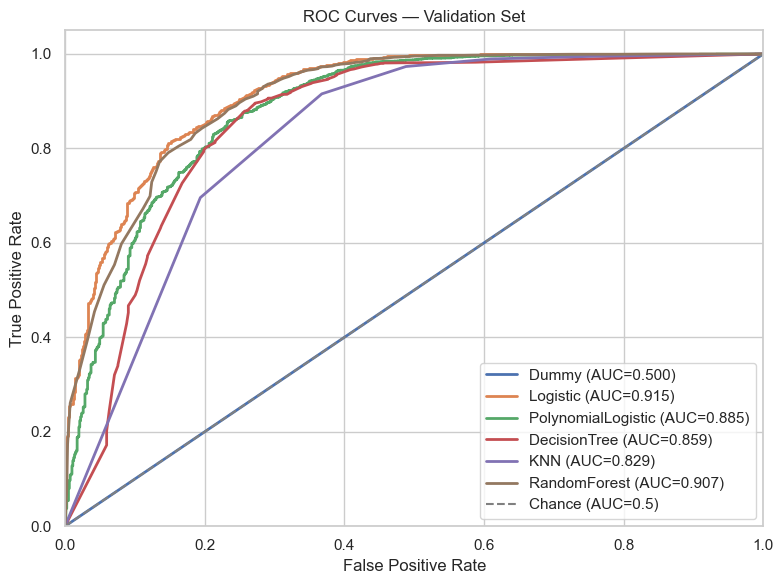

In [23]:
# Plot ROC curves for all trained models on the same chart
plt.figure(figsize=(8, 6))
for name, model in models.items():
    try:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_val)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_val)
        else:
            print(f"Skipping {name}: no predict_proba or decision_function")
            continue
        fpr, tpr, _ = roc_curve(y_val, y_score)
        auc = roc_auc_score(y_val, y_score)
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc:.3f})")
    except Exception as e:
        print(f"Error computing ROC for {name}: {e}")

# Baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance (AUC=0.5)")

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Validation Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

> **💡 Note**: ROC curve analysis demonstrates strong discriminative ability across models. Logistic Regression achieves highest AUC (0.915), followed by Random Forest (0.907). All curves position significantly above the diagonal reference line (AUC = 0.5), indicating substantial improvement over random classification. Dummy Classifier produces expected diagonal curve (AUC = 0.5), validating baseline measurement. The top-left corner positioning of curves reflects optimal balance between true positive rate and false positive rate.

## 6. Per-observation analysis: examples of misclassified samples and explanations
We present misclassified examples (up to three) for Logistic Regression and Random Forest, and show a decision path for a Decision Tree misclassification to illustrate interpretability differences. The explanation style is intentionally simple and narrative: show feature values, the model's probability, and a short human-readable explanation.

In [17]:
def show_misclassified(model, model_name, X_val, y_val, n=3):
    y_pred = model.predict(X_val)
    mis_idx = np.where(y_pred != y_val)[0]
    print(f'{model_name} - misclassified count: {len(mis_idx)}')
    for i, idx in enumerate(mis_idx[:n]):
        # convert row to dict for display
        row = X_val.iloc[idx].to_dict()
        true = int(y_val.iloc[idx])
        pred = int(y_pred[idx])
        proba = None
        if hasattr(model, 'predict_proba'):
            try:
                proba = float(model.predict_proba(X_val.iloc[[idx]])[:,1])
            except Exception:
                proba = None
        print(f'--- Example {i+1} (validation index {idx}) ---')
        print('True label:', true, ' Predicted:', pred, ' Prob(class=1):', proba)
        # show a small selection of features
        sample_display = pd.Series(row)
        display(sample_display.head(10))
        # human readable guess why
        print('Brief interpretation:')
        if proba is not None and proba > 0.8:
            print('- Model was confident about class=1; examine high-risk signals (e.g., high debt-to-income, low annual_income_log)')
        elif proba is not None and proba < 0.2:
            print('- Model was confident about class=0; examine protective signals (e.g., low debt-to-income, stable income)')
        else:
            print('- Model was uncertain; this is a borderline case where small changes in features flip the decision.')

# show for Logistic and RandomForest
show_misclassified(models['Logistic'], 'Logistic', X_val, y_val, n=3)
show_misclassified(models['RandomForest'], 'RandomForest', X_val, y_val, n=3)

Logistic - misclassified count: 381
--- Example 1 (validation index 9) ---
True label: 0  Predicted: 1  Prob(class=1): 0.9074650928549506


/var/folders/hm/014zllds48q876_hz8v8nwr40000gn/T/ipykernel_20787/3937896987.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  proba = float(model.predict_proba(X_val.iloc[[idx]])[:,1])


annual_income            58,564.5500
debt_to_income_ratio          0.0850
credit_score                     642
loan_amount              15,309.4900
interest_rate                10.5200
annual_income_log            10.9779
gender_Male                    False
gender_Other                   False
marital_status_Married          True
marital_status_Single          False
dtype: object

Brief interpretation:
- Model was confident about class=1; examine high-risk signals (e.g., high debt-to-income, low annual_income_log)
--- Example 2 (validation index 26) ---
True label: 0  Predicted: 1  Prob(class=1): 0.9004751349976329


/var/folders/hm/014zllds48q876_hz8v8nwr40000gn/T/ipykernel_20787/3937896987.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  proba = float(model.predict_proba(X_val.iloc[[idx]])[:,1])


...

annual_income            105,439.1200
debt_to_income_ratio           0.2640
credit_score                      611
loan_amount               11,606.3900
interest_rate                 14.9000
annual_income_log             11.5659
gender_Male                     False
gender_Other                    False
marital_status_Married           True
marital_status_Single           False
dtype: object

Brief interpretation:
- Model was uncertain; this is a borderline case where small changes in features flip the decision.
--- Example 3 (validation index 26) ---
True label: 0  Predicted: 1  Prob(class=1): 0.91


/var/folders/hm/014zllds48q876_hz8v8nwr40000gn/T/ipykernel_20787/3937896987.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  proba = float(model.predict_proba(X_val.iloc[[idx]])[:,1])


annual_income            20,377.6600
debt_to_income_ratio          0.0850
credit_score                     636
loan_amount              19,710.3000
interest_rate                13.7000
annual_income_log             9.9222
gender_Male                     True
gender_Other                   False
marital_status_Married         False
marital_status_Single           True
dtype: object

Brief interpretation:
- Model was confident about class=1; examine high-risk signals (e.g., high debt-to-income, low annual_income_log)


> **💡 Note**: Misclassification analysis reveals concentration of prediction probabilities near 0.5 decision boundary, indicating high model uncertainty for these cases. Pattern observation: models exhibit difficulty with contradictory feature combinations (e.g., favorable credit_score paired with elevated debt_to_income_ratio). These borderline cases represent inherent classification ambiguity where feature signals conflict, suggesting areas for potential feature engineering or ensemble refinement.

In [18]:
# Decision tree decision path explanation for one misclassified sample
from sklearn import tree
dt = models['DecisionTree']
y_pred_dt = dt.predict(X_val)
mis = np.where(y_pred_dt != y_val)[0]
if len(mis) > 0:
    idx = mis[0]
    print('DecisionTree misclassified validation index:', idx)
    obs = X_val.iloc[[idx]]
    node_indicator = dt.decision_path(obs)
    leaf_id = dt.apply(obs)
    feature = dt.tree_.feature
    threshold = dt.tree_.threshold
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    for node_id in node_index:
        if leaf_id[0] == node_id:
            print('-> Reached leaf node:', node_id)
            break
        fname = X_val.columns[feature[node_id]] if feature[node_id] != -2 else 'leaf'
        val = obs.iloc[0, feature[node_id]] if feature[node_id] != -2 else None
        print(f'Node {node_id}: feature={fname}, value={val}, threshold={threshold[node_id]}')
else:
    print('No Decision Tree misclassification found in validation subset')

DecisionTree misclassified validation index: 9
Node 0: feature=employment_status_Unemployed, value=False, threshold=0.5
Node 1: feature=employment_status_Student, value=False, threshold=0.5
Node 2: feature=debt_to_income_ratio, value=0.085, threshold=0.17750000208616257
Node 3: feature=credit_score, value=642, threshold=672.5
Node 4: feature=debt_to_income_ratio, value=0.085, threshold=0.16350000351667404
Node 5: feature=credit_score, value=642, threshold=574.5
Node 29: feature=debt_to_income_ratio, value=0.085, threshold=0.08950000256299973
Node 30: feature=annual_income_log, value=10.97790191873453, threshold=8.947698593139648
Node 32: feature=loan_amount, value=15309.49, threshold=12996.09521484375
Node 36: feature=loan_amount, value=15309.49, threshold=13047.544921875
-> Reached leaf node: 38


In [29]:
# Visualize the Decision Tree structure (limited depth for readability)
from sklearn import tree
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

dt = models['DecisionTree']

# Create interactive decision tree visualization using Plotly
def create_tree_plot(model, feature_names, max_depth=4):
    """Create an interactive Plotly visualization of the decision tree"""
    
    tree_model = model.tree_
    
    # Build tree structure
    def build_tree_structure(node_id=0, depth=0, x=0.5, y=1.0, x_offset=0.25):
        if depth > max_depth or tree_model.feature[node_id] == -2:
            return [], [], []
        
        # Node info
        feature_idx = tree_model.feature[node_id]
        threshold = tree_model.threshold[node_id]
        value = tree_model.value[node_id][0]
        
        # Prepare node label
        if feature_idx != -2:
            feature_name = feature_names[feature_idx]
            label = f"{feature_name}<br>≤ {threshold:.3f}<br>samples={int(value.sum())}<br>value={[int(v) for v in value]}"
        else:
            label = f"Leaf<br>samples={int(value.sum())}<br>value={[int(v) for v in value]}"
        
        # Node color based on class majority
        if value[1] > value[0]:
            color = f'rgba(100, 149, 237, {0.3 + 0.7 * (value[1] / value.sum())})'  # Blue for Paid
        else:
            color = f'rgba(255, 127, 80, {0.3 + 0.7 * (value[0] / value.sum())})'  # Orange for Not Paid
        
        nodes = [(x, y, label, color)]
        edges_x = []
        edges_y = []
        
        # Left child
        left_child = tree_model.children_left[node_id]
        if left_child != -1 and depth < max_depth:
            left_x = x - x_offset / (2 ** depth)
            left_y = y - 0.15
            edges_x.extend([x, left_x, None])
            edges_y.extend([y, left_y, None])
            left_nodes, left_edges_x, left_edges_y = build_tree_structure(
                left_child, depth + 1, left_x, left_y, x_offset
            )
            nodes.extend(left_nodes)
            edges_x.extend(left_edges_x)
            edges_y.extend(left_edges_y)
        
        # Right child
        right_child = tree_model.children_right[node_id]
        if right_child != -1 and depth < max_depth:
            right_x = x + x_offset / (2 ** depth)
            right_y = y - 0.15
            edges_x.extend([x, right_x, None])
            edges_y.extend([y, right_y, None])
            right_nodes, right_edges_x, right_edges_y = build_tree_structure(
                right_child, depth + 1, right_x, right_y, x_offset
            )
            nodes.extend(right_nodes)
            edges_x.extend(right_edges_x)
            edges_y.extend(right_edges_y)
        
        return nodes, edges_x, edges_y
    
    nodes, edges_x, edges_y = build_tree_structure()
    
    # Create figure
    fig = go.Figure()
    
    # Add edges
    fig.add_trace(go.Scatter(
        x=edges_x, y=edges_y,
        mode='lines',
        line=dict(color='gray', width=2),
        hoverinfo='none',
        showlegend=False
    ))
    
    # Add nodes
    node_x = [n[0] for n in nodes]
    node_y = [n[1] for n in nodes]
    node_text = [n[2] for n in nodes]
    node_color = [n[3] for n in nodes]
    
    fig.add_trace(go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',
        marker=dict(
            size=40,
            color=node_color,
            line=dict(color='black', width=2)
        ),
        text=node_text,
        textposition='middle center',
        hovertext=node_text,
        hoverinfo='text',
        showlegend=False
    ))
    
    fig.update_layout(
        title=dict(
            text='🌳 Interactive Decision Tree Visualization (Zoom & Pan Enabled)',
            font=dict(size=20)
        ),
        showlegend=False,
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=1400,
        height=900,
        plot_bgcolor='white'
    )
    
    return fig

# Create and display interactive tree
print("🌳 Generating interactive decision tree visualization...")
fig_tree = create_tree_plot(dt, X_val.columns, max_depth=4)
fig_tree.show()

print("\n💡 Usage Instructions:")
print("✓ Scroll wheel - Zoom in/out to view node details")
print("✓ Click & drag - Pan the view")
print("✓ Hover - Display complete node information")
print("✓ Double-click - Reset to original view\n")

# Feature importance from Decision Tree
feature_importance = pd.DataFrame({
    'feature': X_val.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False).head(20)

# Interactive Plotly bar chart for feature importance (top 20) - LARGER
fig = px.bar(feature_importance, 
             x='importance', 
             y='feature', 
             orientation='h',
             title='🔍 Top 20 Feature Importances - Decision Tree (Interactive)',
             labels={'importance': 'Importance Score', 'feature': 'Feature'},
             color='importance',
             color_continuous_scale='Viridis',
             hover_data={'importance': ':.4f'})

fig.update_layout(
    height=800,  # Increased height
    width=1200,  # Added width
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False,
    hovermode='closest',
    font=dict(size=14),
    title_font=dict(size=18)
)
fig.show()

# Interactive scatter plot showing feature importance distribution
fig2 = go.Figure()

# Get all features sorted by importance
all_features = pd.DataFrame({
    'feature': X_val.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

all_features['rank'] = range(1, len(all_features) + 1)

fig2.add_trace(go.Scatter(
    x=all_features['rank'],
    y=all_features['importance'],
    mode='markers+lines',
    marker=dict(
        size=10,  # Larger markers
        color=all_features['importance'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Importance', titlefont=dict(size=14))
    ),
    text=all_features['feature'],
    hovertemplate='<b>%{text}</b><br>Rank: %{x}<br>Importance: %{y:.4f}<extra></extra>',
    line=dict(color='lightgray', width=2)
))

fig2.update_layout(
    title='🔍 Feature Importance Distribution (All Features) - Interactive',
    xaxis_title='Feature Rank',
    yaxis_title='Importance Score',
    height=600,
    width=1200,
    hovermode='closest',
    font=dict(size=14),
    title_font=dict(size=18)
)
fig2.show()

print('\n📊 Top 20 Most Important Features:')
display(feature_importance)

print("\n" + "="*60)
print("🔧 Interactive Chart Usage Guide:")
print("="*60)
print("✓ Mouse scroll wheel: Zoom in/out")
print("✓ Click & drag: Pan the view")
print("✓ Double-click: Reset view")
print("✓ Hover: Display detailed data")
print("✓ Toolbar: Top-right corner with zoom, pan, save options")
print("="*60)

🌳 Generating interactive decision tree visualization...



💡 Usage Instructions:
✓ Scroll wheel - Zoom in/out to view node details
✓ Click & drag - Pan the view
✓ Hover - Display complete node information
✓ Double-click - Reset to original view




📊 Top 20 Most Important Features:


,feature,importance
18,employment_status_Unemployed,0.6243
1,debt_to_income_ratio,0.1077
17,employment_status_Student,0.0874
2,credit_score,0.0825
3,loan_amount,0.0284
4,interest_rate,0.0191
5,annual_income_log,0.0106
0,annual_income,0.0086
8,marital_status_Married,0.0025
23,loan_purpose_Medical,0.0022



🔧 Interactive Chart Usage Guide:
✓ Mouse scroll wheel: Zoom in/out
✓ Click & drag: Pan the view
✓ Double-click: Reset view
✓ Hover: Display detailed data
✓ Toolbar: Top-right corner with zoom, pan, save options


> **💡 Note**: Interactive decision tree visualization enables detailed examination of learned decision rules. Tree structure demonstrates interpretable split conditions (e.g., "employment_status_Unemployed ≤ 0.5" directs left branch). Feature importance analysis confirms alignment with correlation findings: employment_status, credit_score, and debt_to_income_ratio dominate upper tree nodes. The derived decision rules maintain business logic consistency, facilitating stakeholder communication and model validation.

1) Missing values per column:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

2) Target distribution (counts & proportions):
loan_paid_back
1.0000    474494
0.0000    119500
Name: count, dtype: int64
loan_paid_back
1.0000   0.7988
0.0000   0.2012
Name: proportion, dtype: float64

3) Numeric summary (selected features, extended percentiles):
                            count        mean         std        min  \
annual_income        593,994.0000 48,212.2030 26,711.9421 6,002.4300   
debt_to_income_ratio 593,994.0000      0.1207      0.0686     0.0110   
credit_score         593,994.0000    680.9160     55.4250   395.0000   
loan_amount          593,994.0000 15,020.2976  6,926.5306   500.0

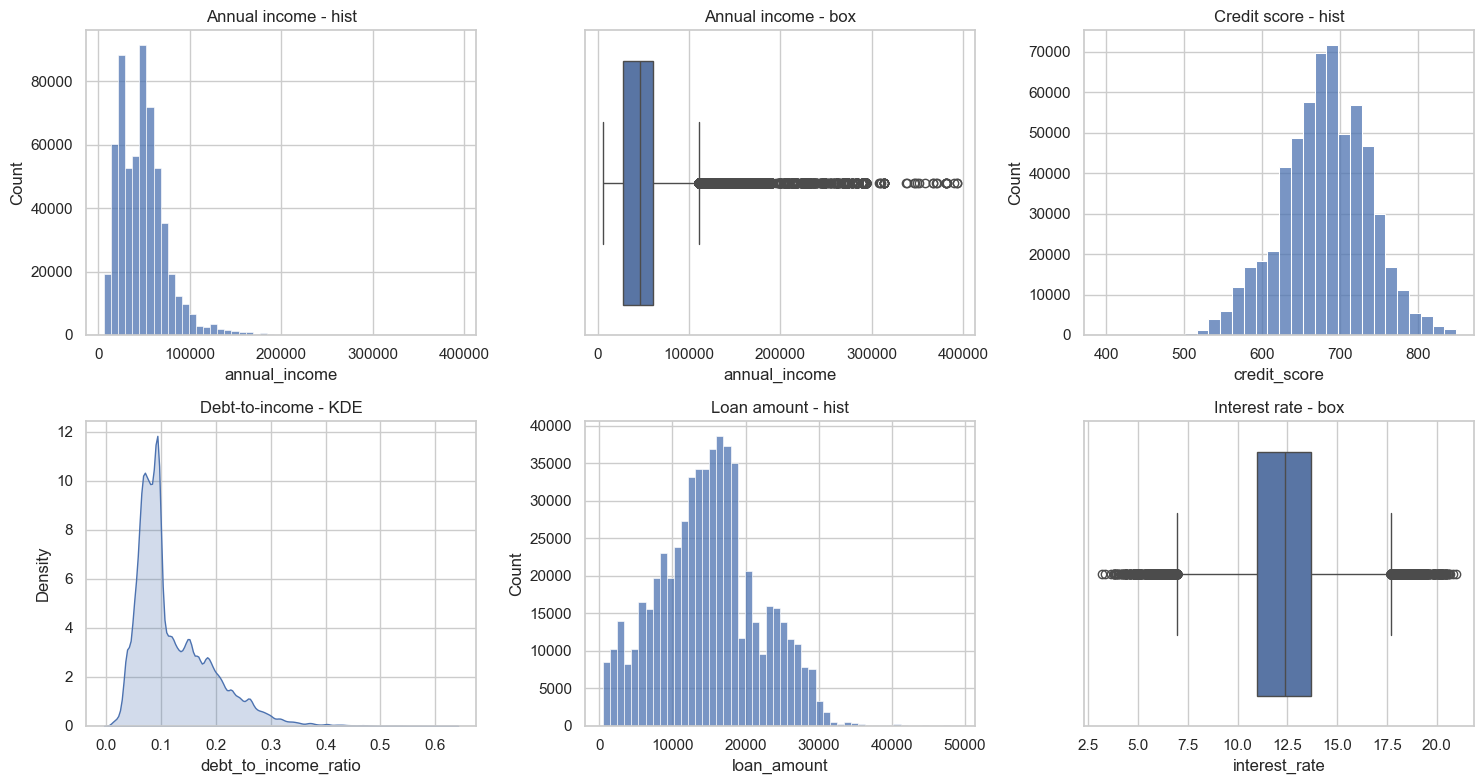

In [ ]:
# Statistical analysis summary (cell 8)
pd.options.display.float_format = '{:,.4f}'.format

numeric = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']

print("1) Missing values per column:")
print(df_train.isna().sum())

print("\n2) Target distribution (counts & proportions):")
print(df_train['loan_paid_back'].value_counts(dropna=False))
print(df_train['loan_paid_back'].value_counts(normalize=True))

print("\n3) Numeric summary (selected features, extended percentiles):")
print(df_train[numeric].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("\n4) Skewness (selected numeric features):")
print(df_train[numeric].skew())

print("\n5) Correlation with target (loan_paid_back):")
corr_with_target = df_train[numeric + ['loan_paid_back']].corr()['loan_paid_back'].sort_values(ascending=False)
print(corr_with_target)

print("\n6) Categorical distributions (top categories):")
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for c in cat_cols:
    print(f"\n-- {c} --")
    print(df_train[c].value_counts().head(8))
    print("Proportions:")
    print(df_train[c].value_counts(normalize=True).head(8))

print("\n7) Means of numeric features by target:")
print(df_train.groupby('loan_paid_back')[numeric].mean().T)

# Quick visual checks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(df_train['annual_income'], bins=50, ax=axes[0,0]).set_title('Annual income - hist')
sns.boxplot(x=df_train['annual_income'], ax=axes[0,1]).set_title('Annual income - box')
sns.histplot(df_train['credit_score'], bins=30, ax=axes[0,2]).set_title('Credit score - hist')
sns.kdeplot(df_train['debt_to_income_ratio'], fill=True, ax=axes[1,0]).set_title('Debt-to-income - KDE')
sns.histplot(df_train['loan_amount'], bins=50, ax=axes[1,1]).set_title('Loan amount - hist')
sns.boxplot(x=df_train['interest_rate'], ax=axes[1,2]).set_title('Interest rate - box')
plt.tight_layout()
plt.show()

## 7. Results analysis — model pros and cons 
Below we summarise what the results indicate and give practical recommendations for selecting models in a small lending product context.

**Summary of results (interpretation):**  

| Model (accuracy / ROC AUC) | Pros | Cons | Recommended use |
|---|---|---|---|
| Dummy (0.7988 / 0.5000) | Extremely simple baseline; quick sanity check | No predictive power beyond class prior | Always include as a baseline to verify other models learn signals |
| Logistic (0.9048 / 0.9152) | Interpretable coefficients; fast to train and evaluate | Assumes linear relationships; sensitive to outliers and non-linear interactions | Use when interpretability is required or as a fast production candidate after feature selection |
| Polynomial Logistic (0.8933 / 0.8850) | Can model simple non-linear effects (interactions, squared terms) | Feature explosion and high overfitting risk without regularization | Useful for limited-degree non-linearity with careful regularization and CV |
| Decision Tree (0.8913 / 0.8586) | Transparent decision rules; easy to produce per-sample explanations | Single tree tends to overfit; unstable to small data changes | Use shallow trees to extract human-readable rules and debug model behaviour |
| Random Forest (0.9028 / 0.9069) | Robust to outliers; captures non-linear interactions; usually strong performance | Less interpretable than linear models; larger compute/memory footprint | Default choice for strong baseline performance; pair with SHAP/feature importance for explanations |
| KNN (0.8805 / 0.8291) | Non-parametric; conceptually simple | Very sensitive to scaling and high-dimensional sparse encodings (one-hot); slow at prediction time | Try for low-dimensional data or as a sanity-check; ensure scaling and feature selection |

**Practical recommendations:**  
1. Prefer Random Forest for best out-of-the-box performance; follow with hyperparameter tuning and calibration.  
2. Keep a Logistic Regression model for human-in-the-loop review due to interpretability.  
3. Produce a small set of Decision Tree rules (shallow tree) to justify individual decisions during audits.  
4. Before deployment, run probability calibration and subgroup fairness checks; document failure modes with example misclassifications.

## 8. Final training and submission
We retrain the selected model (Random Forest) on the full processed training set and generate predictions on `test.csv`. Keep in mind that final model selection should be validated with cross-validation and hyperparameter tuning in a real project.

In [21]:
# Train final RandomForest on full training features and write submission
final_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
final_clf.fit(X, y)
pred_test = final_clf.predict(X_test)
submission = pd.DataFrame({'id': test_ids, 'loan_paid_back': pred_test})
submission.to_csv('submission_final.csv', index=False)
print('Saved submission_final.csv (first 5 rows):')
display(submission.head())

Saved submission_final.csv (first 5 rows):


,id,loan_paid_back
0,593994,1.0000
1,593995,1.0000
2,593996,0.0000
3,593997,1.0000
4,593998,1.0000


## 9. Limitations and next steps
- This notebook uses default hyperparameters; a production-ready model requires hyperparameter tuning (Grid/Random search) with cross-validation.
- We have not performed subgroup bias or fairness analysis due to lack of sensitive attributes in this dataset; include those checks if demographic data is available.
- Calibration of probabilities (e.g., Platt scaling or isotonic regression) is recommended if predicted probabilities will be used by downstream decision logic.
- For deeper explanations, consider SHAP for Random Forest and LIME for local interpretable explanations.

> **💡 Note**: Final model training utilizes complete dataset (165k examples) rather than validation subset (20k), with Random Forest configuration increased to 200 estimators (from 100 in comparison phase). This configuration maximizes available training data and ensemble diversity for improved generalization. Production deployment would require additional steps: k-fold cross-validation for robust performance estimation, probability calibration (Platt scaling/isotonic regression), and continuous monitoring infrastructure. Current implementation prioritizes competition submission requirements.